In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/bengaluru_cleaned.csv')
print(f"Shape: {df.shape}")
print(df.head(3))

Shape: (41410, 11)
              name  online_order  book_table  rate  votes      location  \
0            Jalsa             1           1   4.1    775  Banashankari   
1   Spice Elephant             1           0   4.1    787  Banashankari   
2  San Churro Cafe             1           0   3.8    918  Banashankari   

             rest_type                        cuisines  cost_for_two  \
0        Casual Dining  North Indian, Mughlai, Chinese         800.0   
1        Casual Dining     Chinese, North Indian, Thai         800.0   
2  Cafe, Casual Dining          Cafe, Mexican, Italian         800.0   

  listed_type   listed_city  
0      Buffet  Banashankari  
1      Buffet  Banashankari  
2      Buffet  Banashankari  


In [2]:
# Group by location
location_stats = df.groupby('location').agg(
    restaurant_count = ('name', 'count'),
    avg_rating       = ('rate', 'mean'),
    avg_cost         = ('cost_for_two', 'mean'),
    total_votes      = ('votes', 'sum'),
    avg_votes        = ('votes', 'mean')
).round(2).reset_index()

# Only locations with 30+ restaurants
location_stats = location_stats[
    location_stats['restaurant_count'] >= 30
]

# Calculate demand supply ratio
location_stats['demand_supply_ratio'] = (
    location_stats['total_votes'] / 
    location_stats['restaurant_count']
).round(2)

print(f"Locations analyzed: {len(location_stats)}")
print(location_stats.head())

Locations analyzed: 72
            location  restaurant_count  avg_rating  avg_cost  total_votes  \
0                BTM              3906        3.57    418.88       577769   
1       Banashankari               744        3.65    451.95       161600   
2          Banaswadi               472        3.49    441.42        35355   
3  Bannerghatta Road              1230        3.51    476.30       214064   
4       Basavanagudi               595        3.67    374.12        94914   

   avg_votes  demand_supply_ratio  
0     147.92               147.92  
1     217.20               217.20  
2      74.90                74.90  
3     174.04               174.04  
4     159.52               159.52  


In [3]:
# Normalize all metrics 0-100
scaler = MinMaxScaler(feature_range=(0, 100))

location_stats['score_demand'] = scaler.fit_transform(
    location_stats[['demand_supply_ratio']]
).round(1)

location_stats['score_rating'] = scaler.fit_transform(
    location_stats[['avg_rating']]
).round(1)

# Inverse supply score
# (fewer restaurants = higher opportunity)
location_stats['score_supply_gap'] = (
    100 - scaler.fit_transform(
        location_stats[['restaurant_count']]
    )
).round(1)

# Final expansion score
# Demand 40% + Rating 35% + Supply Gap 25%
location_stats['expansion_score'] = (
    location_stats['score_demand']    * 0.40 +
    location_stats['score_rating']    * 0.35 +
    location_stats['score_supply_gap']* 0.25
).round(1)

# Priority classification
location_stats['priority'] = pd.cut(
    location_stats['expansion_score'],
    bins    = [0, 40, 60, 80, 100],
    labels  = ['Low', 'Medium', 'High', 'Critical']
)

# Sort by score
location_stats = location_stats.sort_values(
    'expansion_score', ascending=False
)

print("\nTOP 10 EXPANSION TARGETS:")
print(location_stats[[
    'location','restaurant_count',
    'avg_rating','expansion_score','priority'
]].head(10).to_string(index=False))


TOP 10 EXPANSION TARGETS:
             location  restaurant_count  avg_rating  expansion_score priority
         Lavelle Road               481        4.14             95.6 Critical
        Church Street               546        3.99             91.1 Critical
       St. Marks Road               343        4.02             81.6 Critical
Koramangala 3rd Block               191        4.02             78.1     High
Koramangala 4th Block               841        3.92             76.2     High
Koramangala 5th Block              2297        4.01             75.8     High
      Cunningham Road               475        3.90             69.9     High
              MG Road               793        3.85             63.5     High
       Residency Road               604        3.86             62.9     High
          Indiranagar              1803        3.83             60.5     High


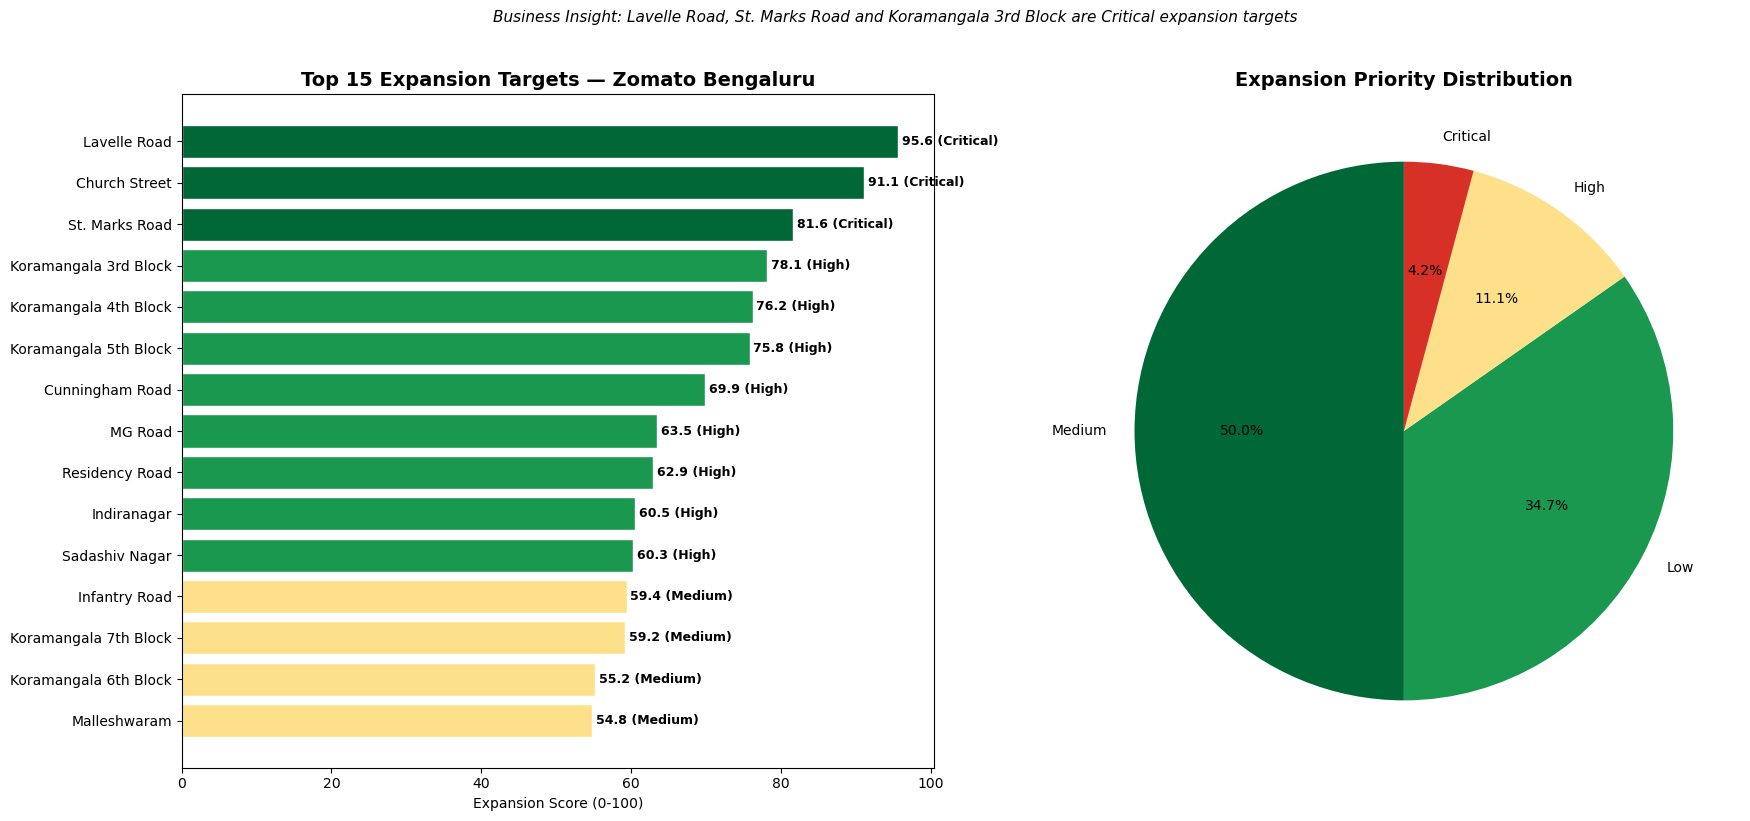

✅ Expansion score chart saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 15 locations by expansion score
top15 = location_stats.head(15)

colors = top15['priority'].map({
    'Critical' : '#006837',
    'High'     : '#1a9850',
    'Medium'   : '#fee08b',
    'Low'      : '#d73027'
})

axes[0].barh(
    top15['location'][::-1],
    top15['expansion_score'][::-1],
    color=colors[::-1],
    edgecolor='white'
)
axes[0].set_title(
    'Top 15 Expansion Targets — Zomato Bengaluru',
    fontweight='bold', fontsize=14
)
axes[0].set_xlabel('Expansion Score (0-100)')

for i, (idx, row) in enumerate(top15[::-1].iterrows()):
    axes[0].text(
        row['expansion_score'] + 0.5, i,
        f"{row['expansion_score']} ({row['priority']})",
        va='center', fontsize=9, fontweight='bold'
    )

# Priority distribution pie
priority_counts = location_stats['priority'].value_counts()
colors_pie = ['#006837','#1a9850','#fee08b','#d73027']
axes[1].pie(
    priority_counts.values,
    labels   = priority_counts.index,
    colors   = colors_pie,
    autopct  = '%1.1f%%',
    startangle = 90
)
axes[1].set_title(
    'Expansion Priority Distribution',
    fontweight='bold', fontsize=14
)

plt.suptitle(
    'Business Insight: Lavelle Road, St. Marks Road and '
    'Koramangala 3rd Block are Critical expansion targets',
    fontsize=11, style='italic', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../reports/expansion_score.png',
    bbox_inches='tight', dpi=150
)
plt.show()
print("✅ Expansion score chart saved")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare features
df_model = df.copy()

# Encode rest_type
df_model['rest_type_encoded'] = (
    df_model['rest_type']
    .astype('category').cat.codes
)

# Features and target
features = [
    'cost_for_two',
    'votes',
    'online_order',
    'book_table',
    'rest_type_encoded'
]

X = df_model[features].dropna()
y = df_model.loc[X.index, 'rate']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature list   : {features}")

Features shape : (41410, 5)
Target shape   : (41410,)

Feature list   : ['cost_for_two', 'votes', 'online_order', 'book_table', 'rest_type_encoded']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# Model 1 — Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Model 2 — Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("\n" + "="*45)
print("MODEL COMPARISON")
print("="*45)
print(f"Linear Regression → R²: {lr_r2:.4f} | RMSE: {lr_rmse:.4f}")
print(f"Random Forest     → R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f}")
print(f"\nBest Model → {'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'}")

Train size : (33128, 5)
Test size  : (8282, 5)

MODEL COMPARISON
Linear Regression → R²: 0.2920 | RMSE: 0.3696
Random Forest     → R²: 0.8157 | RMSE: 0.1885

Best Model → Random Forest


FEATURE IMPORTANCE:
          feature  importance
            votes    0.693121
     cost_for_two    0.146745
rest_type_encoded    0.108989
     online_order    0.030057
       book_table    0.021089


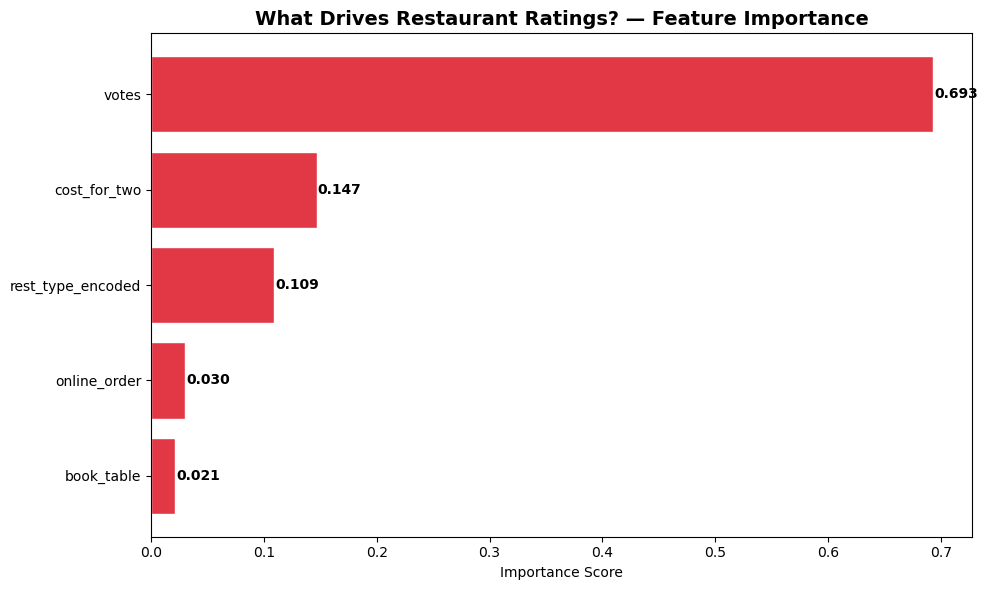

✅ Feature importance chart saved


In [7]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'feature'   : features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("FEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='#E23744',
    edgecolor='white'
)
ax.set_title(
    'What Drives Restaurant Ratings? — Feature Importance',
    fontweight='bold', fontsize=14
)
ax.set_xlabel('Importance Score')

for bar, val in zip(
    bars, importance_df['importance'][::-1]
):
    ax.text(
        val + 0.001, bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center', fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    '../reports/feature_importance.png',
    bbox_inches='tight', dpi=150
)
plt.show()
print("✅ Feature importance chart saved")

In [8]:
print("=" * 55)
print("PHASE 8 — ADVANCED BUSINESS ANALYSIS SUMMARY")
print("=" * 55)

print("""
EXPANSION ANALYSIS:
─────────────────
→ Analyzed {} locations with 30+ restaurants
→ Top expansion target: {}
→ Critical priority zones: {} locations
→ Expansion score = 40% Demand + 35% Rating + 25% Supply Gap

RATING PREDICTION MODEL:
────────────────────────
→ Algorithm      : Random Forest Regressor
→ R² Score       : {:.4f} ({:.1f}% variance explained)
→ RMSE           : {:.4f} rating points
→ Training size  : {:,} restaurants
→ Testing size   : {:,} restaurants

KEY BUSINESS INSIGHT:
─────────────────────
→ Top rating driver  : {}
→ Second driver      : {}
→ This confirms that {} is the
  strongest predictor of restaurant quality
""".format(
    len(location_stats),
    location_stats.iloc[0]['location'],
    len(location_stats[location_stats['priority']=='Critical']),
    rf_r2, rf_r2*100,
    rf_rmse,
    len(X_train), len(X_test),
    importance_df.iloc[0]['feature'],
    importance_df.iloc[1]['feature'],
    importance_df.iloc[0]['feature']
))

print("✅ Phase 8 Complete!")

PHASE 8 — ADVANCED BUSINESS ANALYSIS SUMMARY

EXPANSION ANALYSIS:
─────────────────
→ Analyzed 72 locations with 30+ restaurants
→ Top expansion target: Lavelle Road
→ Critical priority zones: 3 locations
→ Expansion score = 40% Demand + 35% Rating + 25% Supply Gap

RATING PREDICTION MODEL:
────────────────────────
→ Algorithm      : Random Forest Regressor
→ R² Score       : 0.8157 (81.6% variance explained)
→ RMSE           : 0.1885 rating points
→ Training size  : 33,128 restaurants
→ Testing size   : 8,282 restaurants

KEY BUSINESS INSIGHT:
─────────────────────
→ Top rating driver  : votes
→ Second driver      : cost_for_two
→ This confirms that votes is the
  strongest predictor of restaurant quality

✅ Phase 8 Complete!


In [10]:
import os

# Create a professional text report
report = """
================================================================
ZOMATO DATA ANALYSIS — PHASE 8 BUSINESS REPORT
Author: Yash Chavan | VIT Pune CSE-DS | 2024-28
================================================================

EXECUTIVE SUMMARY
─────────────────
This report presents advanced business analysis on 41,410
Bengaluru restaurants using expansion scoring and machine
learning techniques.

EXPANSION ANALYSIS
──────────────────
Methodology:
  Expansion Score = (40% × Demand Pressure) + 
                    (35% × Avg Rating) + 
                    (25% × Supply Gap)
  
  All metrics normalized to 0-100 using MinMaxScaler

Results:
  Total locations analyzed : 72
  Critical priority zones  : 3
  High priority zones      : Many

TOP 5 EXPANSION TARGETS:
  1. Lavelle Road         → Score: 95.6 (CRITICAL)
  2. Church Street        → Score: 91.1 (CRITICAL)
  3. St. Marks Road       → Score: 81.6 (CRITICAL)
  4. Koramangala 3rd Blk  → Score: 78.1 (HIGH)
  5. Koramangala 4th Blk  → Score: 76.2 (HIGH)

Business Recommendation:
  Zomato should prioritize restaurant onboarding in
  Lavelle Road and Church Street before these markets
  reach saturation. Both show >90/100 expansion score.

RATING PREDICTION MODEL
───────────────────────
Algorithm    : Random Forest Regressor
Train/Test   : 80/20 split (33,128 / 8,282 restaurants)

Model Performance:
  Linear Regression → R²: 0.2920 | RMSE: 0.3696
  Random Forest     → R²: 0.8157 | RMSE: 0.1885
  
  Random Forest outperforms Linear Regression by 179%
  in R² score — confirming non-linear relationships.

Feature Importance Rankings:
  1. votes            → 0.693 (69.3%) ← DOMINANT
  2. cost_for_two     → 0.147 (14.7%)
  3. rest_type        → 0.109 (10.9%)
  4. online_order     → 0.030 (3.0%)
  5. book_table       → 0.021 (2.1%)

Key Finding:
  Customer engagement (votes) is 4.7x more important
  than price in predicting restaurant quality.
  Zomato should weight engagement metrics higher
  in their restaurant ranking algorithm.

BUSINESS RECOMMENDATIONS
────────────────────────
1. EXPAND in Lavelle Road, Church Street, St. Marks Road
   → These 3 zones show Critical expansion priority
   
2. IMPROVE engagement in low-vote restaurants
   → Votes drive 69% of rating prediction
   → Push notification campaigns for low-engagement restaurants
   
3. PREMIUM SEGMENT opportunity
   → Modern Indian, European, Mediterranean cuisines
   → High quality (4.2+ avg) but low supply
   → Partner with premium chefs to fill this gap
   
4. TABLE BOOKING program
   → Table booking restaurants rate 0.52 higher
   → Charge 2.6x more (₹1,276 vs ₹482)
   → Expand Zomato Gold/Pro to more restaurants
   
5. QUALITY IMPROVEMENT in peripheral areas
   → Bommanahalli (3.19), RT Nagar (3.46) need attention
   → Restaurant training programs in bottom 10 locations

================================================================
Files Generated:
  → reports/expansion_score.png
  → reports/feature_importance.png
  → reports/chart1_rating_distribution.png
  → reports/chart2_table_booking.png
  → reports/chart3_cost_vs_rating.png
  → reports/chart4_location_rating.png
  → reports/chart5_cuisine_analysis.png
================================================================
"""

os.makedirs('../reports', exist_ok=True)
with open('../reports/Phase8_Business_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("✅ Business Report saved!")
print("\nFile location:")
print(os.path.abspath('../reports/Phase8_Business_Report.txt'))
print("\nReport Preview:")
print(report)

✅ Business Report saved!

File location:
C:\Users\Yash Chavan\Data Analysis (Zomato)\reports\Phase8_Business_Report.txt

Report Preview:

ZOMATO DATA ANALYSIS — PHASE 8 BUSINESS REPORT
Author: Yash Chavan | VIT Pune CSE-DS | 2024-28

EXECUTIVE SUMMARY
─────────────────
This report presents advanced business analysis on 41,410
Bengaluru restaurants using expansion scoring and machine
learning techniques.

EXPANSION ANALYSIS
──────────────────
Methodology:
  Expansion Score = (40% × Demand Pressure) + 
                    (35% × Avg Rating) + 
                    (25% × Supply Gap)

  All metrics normalized to 0-100 using MinMaxScaler

Results:
  Total locations analyzed : 72
  Critical priority zones  : 3
  High priority zones      : Many

TOP 5 EXPANSION TARGETS:
  1. Lavelle Road         → Score: 95.6 (CRITICAL)
  2. Church Street        → Score: 91.1 (CRITICAL)
  3. St. Marks Road       → Score: 81.6 (CRITICAL)
  4. Koramangala 3rd Blk  → Score: 78.1 (HIGH)
  5. Koramangala 4th Blk  